# Week 2.4: RAG 101 - Retrieval Systems

## Key Insight
> **The pipeline: Load → Split → Embed → Retrieve → Answer**

## Learning Objectives
By the end of this notebook, you will:
- RAG architecture and pipeline
- Document loading and preprocessing
- Chunking strategies for optimal retrieval
- Vector stores and similarity search
- Generating answers with retrieved context

## Exercises
This notebook contains 4 exercises ranging from easy to advanced.

## Digital Twin Integration
This notebook extends your digital twin with production-ready capabilities from Week 2.

In [1]:
# Setup and imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Any, Tuple
import re
import json

print('✅ Week 2.4: RAG 101 - Retrieval Systems - Ready to start!')
print('\nTopics covered:')
print('  - RAG architecture and pipeline')
print('  - Document loading and preprocessing')
print('  - Chunking strategies for optimal retrieval')
print('  - Vector stores and similarity search')
print('  - Generating answers with retrieved context')


✅ Week 2.4: RAG 101 - Retrieval Systems - Ready to start!

Topics covered:
  - RAG architecture and pipeline
  - Document loading and preprocessing
  - Chunking strategies for optimal retrieval
  - Vector stores and similarity search
  - Generating answers with retrieved context


---
## Part 1: Introduction to RAG architecture and pipeline

Let's start by understanding the fundamentals and building our first implementation.

In [ ]:
# Example implementation
# This is a starter template - expand with your implementation

class ExampleClass:
    """
    Example class for RAG architecture and pipeline.
    """

    def __init__(self):
        self.data = []

    def process(self, input_data):
        """
        Process the input data.
        """
        # Add your implementation here
        return input_data

# Test the class
example = ExampleClass()
result = example.process('test data')
print(f'Result: {result}')

### 🎯 Exercise 1 (Easy): Getting Started

**Task**: Implement a basic version of the concept introduced above.

**Requirements**:
1. Follow the pattern shown in the example
2. Test your implementation with sample data
3. Verify the output matches expectations
4. Add error handling for edge cases

In [2]:
import re
from typing import List, Dict, Any


class SimpleRAG:
    """
    Minimal RAG pipeline: load → split → (stub for embed/retrieve).

    Exercise 1 scope:
        - Add documents to a knowledge base
        - Split them into overlapping chunks
        - Verify chunks preserve content and order
        - Handle edge cases (empty docs, bad types, bad chunk sizes)
    """

    def __init__(self, chunk_size: int = 200, overlap: int = 50):
        # --- Validation ---
        if not isinstance(chunk_size, int):
            raise TypeError(
                f"chunk_size must be int, got {type(chunk_size).__name__}"
            )
        if chunk_size <= 0:
            raise ValueError(f"chunk_size must be > 0, got {chunk_size}")
        if not isinstance(overlap, int):
            raise TypeError(
                f"overlap must be int, got {type(overlap).__name__}"
            )
        if overlap < 0:
            raise ValueError(f"overlap must be >= 0, got {overlap}")
        if overlap >= chunk_size:
            raise ValueError(
                f"overlap ({overlap}) must be < chunk_size ({chunk_size})"
            )

        self.chunk_size = chunk_size
        self.overlap = overlap
        self.documents: List[Dict[str, Any]] = []
        self.chunks: List[Dict[str, Any]] = []

    def add_document(self, text: str, doc_id: str = None) -> int:
        """Add a document. Returns the document index."""
        # --- Validation ---
        if not isinstance(text, str):
            raise TypeError(
                f"text must be str, got {type(text).__name__}"
            )
        if not text.strip():
            raise ValueError("document text cannot be empty")

        if doc_id is None:
            doc_id = f"doc_{len(self.documents)}"
        elif not isinstance(doc_id, str):
            raise TypeError(
                f"doc_id must be str, got {type(doc_id).__name__}"
            )

        doc = {
            "id": doc_id,
            "text": text,
            "n_chars": len(text),
            "n_words": len(text.split()),
        }
        self.documents.append(doc)
        return len(self.documents) - 1

    def _split_document(self, text: str) -> List[str]:
        """
        Split text into overlapping chunks.

        Strategy: word-based with overlap. More robust than character-based
        because it never splits mid-word.
        """
        words = text.split()
        if not words:
            return []

        chunks = []
        step = self.chunk_size - self.overlap
        for start in range(0, len(words), step):
            chunk_words = words[start:start + self.chunk_size]
            if chunk_words:
                chunks.append(" ".join(chunk_words))
            if start + self.chunk_size >= len(words):
                break
        return chunks

    def build_chunks(self) -> int:
        """Split all stored documents into chunks. Returns total chunk count."""
        self.chunks = []
        for doc in self.documents:
            doc_chunks = self._split_document(doc["text"])
            for i, chunk_text in enumerate(doc_chunks):
                self.chunks.append({
                    "doc_id": doc["id"],
                    "chunk_index": i,
                    "text": chunk_text,
                    "n_words": len(chunk_text.split()),
                })
        return len(self.chunks)

    def process(self, text: str) -> List[str]:
        """Convenience: split a single text into chunks without storing."""
        if not isinstance(text, str):
            raise TypeError(f"text must be str, got {type(text).__name__}")
        return self._split_document(text)

    def summary(self) -> Dict[str, Any]:
        return {
            "documents": len(self.documents),
            "chunks": len(self.chunks),
            "chunk_size": self.chunk_size,
            "overlap": self.overlap,
        }

In [3]:
# --- Sample documents (pretend these are digital twin knowledge entries) ---
docs = [
    "Alex loves outdoor activities like hiking and camping but hates crowded places. "
    "On weekends, Alex usually wakes at 6am to exercise before the day gets busy.",

    "Alex works a standard 9-to-5 job in software engineering. Weekday evenings are "
    "typically spent reading sci-fi novels or cooking Italian food.",

    "Alex's favorite music genre is jazz, especially live performances in small venues. "
    "Loud concerts with large crowds are not appealing.",

    "For vacations, Alex prefers quiet mountain cabins over beach resorts. Recent trips "
    "include a solo hiking trip in the Rockies and a writing retreat in Vermont.",
]

# --- Build the RAG store ---
rag = SimpleRAG(chunk_size=20, overlap=5)

for doc in docs:
    rag.add_document(doc)

print("Added documents:")
for d in rag.documents:
    print(f"  {d['id']}: {d['n_words']} words")

# --- Build chunks ---
n_chunks = rag.build_chunks()
print(f"\nTotal chunks: {n_chunks}\n")

# --- Inspect chunks ---
print("Chunks per document:")
for c in rag.chunks:
    print(f"  [{c['doc_id']} / chunk {c['chunk_index']}] "
          f"({c['n_words']} words): {c['text'][:60]}...")

Added documents:
  doc_0: 26 words
  doc_1: 21 words
  doc_2: 20 words
  doc_3: 26 words

Total chunks: 7

Chunks per document:
  [doc_0 / chunk 0] (20 words): Alex loves outdoor activities like hiking and camping but ha...
  [doc_0 / chunk 1] (11 words): usually wakes at 6am to exercise before the day gets busy....
  [doc_1 / chunk 0] (20 words): Alex works a standard 9-to-5 job in software engineering. We...
  [doc_1 / chunk 1] (6 words): sci-fi novels or cooking Italian food....
  [doc_2 / chunk 0] (20 words): Alex's favorite music genre is jazz, especially live perform...
  [doc_3 / chunk 0] (20 words): For vacations, Alex prefers quiet mountain cabins over beach...
  [doc_3 / chunk 1] (11 words): hiking trip in the Rockies and a writing retreat in Vermont....


In [4]:
def verify_rag():
    """Sanity checks — all assertions should pass."""
    rag = SimpleRAG(chunk_size=10, overlap=3)

    # 1. Adding documents
    idx = rag.add_document("one two three four five six seven eight nine ten eleven twelve")
    assert idx == 0, "First doc should have index 0"
    assert len(rag.documents) == 1

    # 2. Chunking
    n = rag.build_chunks()
    assert n >= 2, f"Expected at least 2 chunks for 12 words / size 10, got {n}"

    # 3. Overlap preserves content — the first word of chunk 1 should appear
    #    in the tail of chunk 0
    first_chunk_words = set(rag.chunks[0]["text"].split())
    second_chunk_words = set(rag.chunks[1]["text"].split())
    overlap_present = first_chunk_words & second_chunk_words
    assert overlap_present, "No overlap between consecutive chunks"

    # 4. Chunks contain only words from the original text
    all_chunk_words = set()
    for c in rag.chunks:
        all_chunk_words.update(c["text"].split())
    original_words = set("one two three four five six seven eight nine ten eleven twelve".split())
    assert all_chunk_words.issubset(original_words), "Chunk has words not in source"

    print("✅ All verification assertions passed")


verify_rag()

✅ All verification assertions passed


In [5]:
def test_errors():
    print("Error handling tests:")
    print("-" * 50)

    cases = [
        ("chunk_size=0",       lambda: SimpleRAG(chunk_size=0)),
        ("chunk_size='a'",     lambda: SimpleRAG(chunk_size="a")),
        ("overlap=-1",         lambda: SimpleRAG(overlap=-1)),
        ("overlap >= size",    lambda: SimpleRAG(chunk_size=10, overlap=10)),
    ]
    for name, fn in cases:
        try:
            fn()
            print(f"  ❌ {name}: no error raised")
        except (TypeError, ValueError) as e:
            print(f"  ✅ {name}: {type(e).__name__}: {e}")

    # Runtime errors
    rag = SimpleRAG()

    try:
        rag.add_document("")
    except ValueError as e:
        print(f"  ✅ empty doc: ValueError: {e}")

    try:
        rag.add_document(None)
    except TypeError as e:
        print(f"  ✅ None doc: TypeError: {e}")

    try:
        rag.add_document(123)
    except TypeError as e:
        print(f"  ✅ int doc: TypeError: {e}")

    try:
        rag.add_document("ok", doc_id=42)
    except TypeError as e:
        print(f"  ✅ bad doc_id: TypeError: {e}")

    try:
        rag.process(123)
    except TypeError as e:
        print(f"  ✅ process non-str: TypeError: {e}")


test_errors()

Error handling tests:
--------------------------------------------------
  ✅ chunk_size=0: ValueError: chunk_size must be > 0, got 0
  ✅ chunk_size='a': TypeError: chunk_size must be int, got str
  ✅ overlap=-1: ValueError: overlap must be >= 0, got -1
  ✅ overlap >= size: ValueError: overlap (10) must be < chunk_size (10)
  ✅ empty doc: ValueError: document text cannot be empty
  ✅ None doc: TypeError: text must be str, got NoneType
  ✅ int doc: TypeError: text must be str, got int
  ✅ bad doc_id: TypeError: doc_id must be str, got int
  ✅ process non-str: TypeError: text must be str, got int


---
## Part 2: Document loading and preprocessing

Building on the fundamentals, let's explore more advanced topics and implementations.

In [ ]:
# Advanced implementation example

def advanced_function(data: List[Any], **kwargs) -> Dict[str, Any]:
    """
    Advanced function for Document loading and preprocessing.

    Args:
        data: Input data to process
        **kwargs: Additional parameters

    Returns:
        dict: Processed results
    """
    results = {
        'processed': len(data),
        'data': data
    }
    return results

# Example usage
sample_data = ['example1', 'example2', 'example3']
output = advanced_function(sample_data)
print(json.dumps(output, indent=2))

### 🎯 Exercise 2 (Intermediate): Building on the Basics

**Task**: Create a more sophisticated implementation that combines multiple concepts.

**Requirements**:
1. Use the patterns from Part 1 and Part 2
2. Add parameter validation
3. Include helpful error messages
4. Test with various input types

In [6]:
import os
import re
import json
from typing import List, Dict, Any, Optional
from datetime import datetime


class DocumentLoader:
    """
    Load and preprocess documents for the RAG pipeline.

    Supports:
        - Loading from strings, files, or lists
        - Cleaning: whitespace, punctuation, HTML, control chars
        - Boilerplate removal (page numbers, headers, footers)
        - Metadata extraction (id, source, date, word count)
        - Token-aware chunking

    The output is a list of dicts, each ready to be embedded:
        {
            "id": "...",
            "source": "...",
            "text": "cleaned text",
            "metadata": {"n_words": ..., "n_chars": ..., "loaded_at": ...}
        }
    """

    # Patterns for boilerplate removal
    BOILERPLATE_PATTERNS = [
        r'^\s*Page\s+\d+\s*(of\s+\d+)?\s*$',      # "Page 1 of 5"
        r'^\s*---+\s*$',                           # Horizontal rules
        r'^\s*Copyright.*$',                       # Copyright lines
        r'^\s*All rights reserved.*$',
        r'^\s*Confidential.*$',
        r'^\s*\d+\s*$',                            # Standalone page numbers
    ]

    def __init__(
        self,
        strip_html: bool = True,
        remove_boilerplate: bool = True,
        normalize_whitespace: bool = True,
        lowercase: bool = False,
        min_length: int = 20,
    ):
        # --- Validation ---
        for name, val in [
            ("strip_html", strip_html),
            ("remove_boilerplate", remove_boilerplate),
            ("normalize_whitespace", normalize_whitespace),
            ("lowercase", lowercase),
        ]:
            if not isinstance(val, bool):
                raise TypeError(f"{name} must be bool, got {type(val).__name__}")

        if not isinstance(min_length, int) or min_length < 0:
            raise ValueError(f"min_length must be a non-negative int, got {min_length!r}")

        self.strip_html = strip_html
        self.remove_boilerplate = remove_boilerplate
        self.normalize_whitespace = normalize_whitespace
        self.lowercase = lowercase
        self.min_length = min_length

    # ----------------------------------------------------------
    # Cleaning helpers
    # ----------------------------------------------------------
    def _strip_html(self, text: str) -> str:
        """Remove HTML tags and decode common entities."""
        # Remove <script> and <style> blocks entirely
        text = re.sub(r'<(script|style)[^>]*>.*?</\1>', '', text,
                      flags=re.DOTALL | re.IGNORECASE)
        # Remove all remaining tags
        text = re.sub(r'<[^>]+>', ' ', text)
        # Decode common entities
        entities = {
            '&nbsp;': ' ', '&amp;': '&', '&lt;': '<',
            '&gt;': '>', '&quot;': '"', '&#39;': "'",
        }
        for entity, char in entities.items():
            text = text.replace(entity, char)
        return text

    def _remove_boilerplate(self, text: str) -> str:
        """Remove common boilerplate lines."""
        lines = text.split('\n')
        cleaned = []
        for line in lines:
            if any(re.match(p, line, re.IGNORECASE) for p in self.BOILERPLATE_PATTERNS):
                continue
            cleaned.append(line)
        return '\n'.join(cleaned)

    def _normalize_whitespace(self, text: str) -> str:
        """Collapse runs of whitespace, strip edges."""
        # Replace tabs with spaces
        text = text.replace('\t', ' ')
        # Collapse multiple spaces
        text = re.sub(r' +', ' ', text)
        # Collapse multiple newlines (max 2 in a row)
        text = re.sub(r'\n\s*\n\s*\n+', '\n\n', text)
        # Strip each line
        lines = [line.strip() for line in text.split('\n')]
        return '\n'.join(lines).strip()

    def clean(self, text: str) -> str:
        """Apply the full cleaning pipeline."""
        if not isinstance(text, str):
            raise TypeError(f"text must be str, got {type(text).__name__}")

        if self.strip_html:
            text = self._strip_html(text)
        if self.remove_boilerplate:
            text = self._remove_boilerplate(text)
        if self.normalize_whitespace:
            text = self._normalize_whitespace(text)
        if self.lowercase:
            text = text.lower()

        return text

    # ----------------------------------------------------------
    # Loading
    # ----------------------------------------------------------
    def load_string(self, text: str, source: str = "inline") -> Dict[str, Any]:
        """Load a single document from a string."""
        if not isinstance(text, str):
            raise TypeError(f"text must be str, got {type(text).__name__}")
        if not isinstance(source, str):
            raise TypeError(f"source must be str, got {type(source).__name__}")

        cleaned = self.clean(text)

        if len(cleaned) < self.min_length:
            raise ValueError(
                f"Document from '{source}' too short after cleaning "
                f"({len(cleaned)} chars < min_length {self.min_length})"
            )

        return self._make_record(cleaned, source)

    def load_file(self, path: str, encoding: str = "utf-8") -> Dict[str, Any]:
        """Load a document from a file."""
        if not isinstance(path, str):
            raise TypeError(f"path must be str, got {type(path).__name__}")
        if not os.path.exists(path):
            raise FileNotFoundError(f"File not found: {path}")
        if not os.path.isfile(path):
            raise ValueError(f"Path is not a file: {path}")

        with open(path, "r", encoding=encoding) as f:
            raw = f.read()

        return self.load_string(raw, source=os.path.basename(path))

    def load_batch(self, items: List[Any], source_prefix: str = "doc") -> List[Dict[str, Any]]:
        """
        Load a batch of strings or file paths.
        Individual failures are logged but do not stop the batch.
        """
        if not isinstance(items, (list, tuple)):
            raise TypeError(f"items must be list, got {type(items).__name__}")
        if not items:
            raise ValueError("items cannot be empty")

        records = []
        errors = []

        for i, item in enumerate(items):
            try:
                if isinstance(item, str) and os.path.isfile(item):
                    rec = self.load_file(item)
                else:
                    rec = self.load_string(item, source=f"{source_prefix}_{i}")
                records.append(rec)
            except (TypeError, ValueError, FileNotFoundError) as e:
                errors.append({"index": i, "error": str(e)})

        return records, errors

    # ----------------------------------------------------------
    # Record construction
    # ----------------------------------------------------------
    def _make_record(self, text: str, source: str) -> Dict[str, Any]:
        """Wrap cleaned text in a standard record."""
        return {
            "id": f"{source}_{datetime.now().strftime('%Y%m%d%H%M%S%f')}",
            "source": source,
            "text": text,
            "metadata": {
                "n_words": len(text.split()),
                "n_chars": len(text),
                "loaded_at": datetime.now().isoformat(timespec="seconds"),
            },
        }

    def summary(self, records: List[Dict[str, Any]]) -> Dict[str, Any]:
        """Aggregate statistics over a batch of records."""
        if not records:
            return {"count": 0}
        n_words = [r["metadata"]["n_words"] for r in records]
        n_chars = [r["metadata"]["n_chars"] for r in records]
        return {
            "count": len(records),
            "total_words": sum(n_words),
            "total_chars": sum(n_chars),
            "avg_words": round(sum(n_words) / len(n_words), 1),
            "min_words": min(n_words),
            "max_words": max(n_words),
            "sources": sorted({r["source"] for r in records}),
        }

In [7]:
loader = DocumentLoader(min_length=20)

# --- Test 1: Messy inline string ---
messy = """
    <html><body>
    <h1>Alex's Profile</h1>
    <script>console.log('tracking')</script>
    <p>Alex loves   outdoor activities like hiking &amp; camping.</p>
    <p>Alex hates crowded places.</p>
    </body></html>

    Page 1 of 1

    Copyright 2026 Alex Corp. All rights reserved.
"""

record = loader.load_string(messy, source="alex_profile")
print("Test 1 — Cleaned string:")
print(f"  Source: {record['source']}")
print(f"  Text:   {repr(record['text'][:80])}...")
print(f"  Words:  {record['metadata']['n_words']}")
print()

# --- Test 2: Batch of documents (mixed types) ---
batch = [
    "Alex works as a software engineer from 9 to 5.",
    "<p>On weekends, Alex typically wakes at <b>6am</b> to exercise.</p>",
    "Alex's favorite music is jazz, especially live performances.",
    "Alex dislikes loud concerts and large crowds.",
]

records, errors = loader.load_batch(batch, source_prefix="alex")
print("Test 2 — Batch loading:")
print(f"  Loaded: {len(records)} records")
print(f"  Errors: {len(errors)}")
print()

# --- Test 3: Summary statistics ---
print("Test 3 — Summary:")
summary = loader.summary(records)
print(json.dumps(summary, indent=2))

Test 1 — Cleaned string:
  Source: alex_profile
  Text:   "Alex's Profile\n\nAlex loves outdoor activities like hiking & camping.\nAlex hates "...
  Words:  14

Test 2 — Batch loading:
  Loaded: 4 records
  Errors: 0

Test 3 — Summary:
{
  "count": 4,
  "total_words": 34,
  "total_chars": 204,
  "avg_words": 8.5,
  "min_words": 7,
  "max_words": 10,
  "sources": [
    "alex_0",
    "alex_1",
    "alex_2",
    "alex_3"
  ]
}


In [8]:
def test_validation():
    print("Parameter validation tests:")
    print("-" * 50)

    # Constructor validation
    cases = [
        ("strip_html='yes'",     lambda: DocumentLoader(strip_html="yes")),
        ("lowercase=1",          lambda: DocumentLoader(lowercase=1)),
        ("min_length=-1",        lambda: DocumentLoader(min_length=-1)),
        ("min_length='a'",       lambda: DocumentLoader(min_length="a")),
    ]
    for name, fn in cases:
        try:
            fn()
            print(f"  ❌ {name}: no error")
        except (TypeError, ValueError) as e:
            print(f"  ✅ {name}: {type(e).__name__}: {e}")

    # Method validation
    loader = DocumentLoader()

    try:
        loader.load_string(None)
    except TypeError as e:
        print(f"  ✅ load_string(None): TypeError: {e}")

    try:
        loader.load_string(123)
    except TypeError as e:
        print(f"  ✅ load_string(123): TypeError: {e}")

    try:
        loader.load_string("", source="empty")
    except ValueError as e:
        print(f"  ✅ empty string: ValueError: {e}")

    try:
        loader.load_string("short", source="tiny")
    except ValueError as e:
        print(f"  ✅ too short: ValueError: {e}")

    try:
        loader.load_file("nonexistent.txt")
    except FileNotFoundError as e:
        print(f"  ✅ missing file: FileNotFoundError: {e}")

    try:
        loader.load_batch([])
    except ValueError as e:
        print(f"  ✅ empty batch: ValueError: {e}")

    try:
        loader.load_batch("not a list")
    except TypeError as e:
        print(f"  ✅ non-list batch: TypeError: {e}")


test_validation()

Parameter validation tests:
--------------------------------------------------
  ✅ strip_html='yes': TypeError: strip_html must be bool, got str
  ✅ lowercase=1: TypeError: lowercase must be bool, got int
  ✅ min_length=-1: ValueError: min_length must be a non-negative int, got -1
  ✅ min_length='a': ValueError: min_length must be a non-negative int, got 'a'
  ✅ load_string(None): TypeError: text must be str, got NoneType
  ✅ load_string(123): TypeError: text must be str, got int
  ✅ empty string: ValueError: Document from 'empty' too short after cleaning (0 chars < min_length 20)
  ✅ too short: ValueError: Document from 'tiny' too short after cleaning (5 chars < min_length 20)
  ✅ missing file: FileNotFoundError: File not found: nonexistent.txt
  ✅ empty batch: ValueError: items cannot be empty
  ✅ non-list batch: TypeError: items must be list, got str


In [9]:
batch_with_errors = [
    "A valid sentence about Alex's preferences.",       # ✅ ok
    "",                                                  # ❌ too short
    123,                                                 # ❌ wrong type
    "Another valid sentence about Alex's routine.",     # ✅ ok
    None,                                                # ❌ wrong type
]

records, errors = loader.load_batch(batch_with_errors, source_prefix="mixed")
print(f"Loaded: {len(records)} valid records")
print(f"Errors: {len(errors)}")
for e in errors:
    print(f"  Index {e['index']}: {e['error']}")

Loaded: 2 valid records
Errors: 3
  Index 1: Document from 'mixed_1' too short after cleaning (0 chars < min_length 20)
  Index 2: text must be str, got int
  Index 4: text must be str, got NoneType


In [10]:
def verify_loader():
    """Sanity checks — all should pass."""
    loader = DocumentLoader(min_length=10)

    # 1. HTML stripped
    rec = loader.load_string("<p>Hello <b>world</b>!</p>", source="t1")
    assert "<p>" not in rec["text"], "HTML not stripped"
    assert "<b>" not in rec["text"], "HTML not stripped"
    assert "hello" in rec["text"].lower() or "Hello" in rec["text"]
    assert "world" in rec["text"]

    # 2. Whitespace normalized
    rec = loader.load_string("hello    world\n\n\n\nfoo", source="t2")
    assert "    " not in rec["text"], "Whitespace not collapsed"
    assert "\n\n\n" not in rec["text"], "Too many blank lines"

    # 3. Boilerplate removed
    rec = loader.load_string(
        "Page 1 of 5\nReal content here that is long enough.\nCopyright 2026.",
        source="t3"
    )
    assert "Page 1" not in rec["text"], "Page number not removed"
    assert "Copyright" not in rec["text"], "Copyright not removed"
    assert "Real content" in rec["text"]

    # 4. Metadata present
    rec = loader.load_string("A proper sentence for testing.", source="t4")
    assert "metadata" in rec
    assert rec["metadata"]["n_words"] > 0
    assert rec["metadata"]["n_chars"] == len(rec["text"])

    # 5. Lowercase option
    lower_loader = DocumentLoader(lowercase=True, min_length=10)
    rec = lower_loader.load_string("HELLO WORLD FOO BAR", source="t5")
    assert rec["text"] == rec["text"].lower(), "Not lowercased"

    print("✅ All verification assertions passed")


verify_loader()

✅ All verification assertions passed


---
## Part 3: Chunking strategies for optimal retrieval

Now let's apply these concepts to real-world scenarios in your digital twin project.

In [ ]:
# Visualization example
import matplotlib.pyplot as plt

def visualize_results(data: List[Any]):
    """
    Visualize the processing results.
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    # Add your visualization code here
    ax.set_title('Results Visualization')
    ax.set_xlabel('X-axis')
    ax.set_ylabel('Y-axis')

    plt.tight_layout()
    plt.show()

# Example: visualize_results(sample_data)

### 🎯 Exercise 3 (Advanced): Complete Implementation

**Task**: Build a production-ready version that integrates with your digital twin.

**Requirements**:
1. Combine all concepts from this notebook
2. Add comprehensive error handling
3. Include logging and debugging capabilities
4. Create visualization of results
5. Write documentation for your implementation

In [11]:
"""
rag_system.py
=============

Production RAG pipeline for the digital twin.

PIPELINE
--------
    Load → Split → Embed → Retrieve → Answer

FEATURES
--------
- 3 chunking strategies: fixed, sentence, recursive
- Embedding-based retrieval with cosine similarity
- Metadata filtering (by source, date, tag)
- Structured logging of every operation
- Visualization of chunk coverage and retrieval scores
- LLM-grounded answers via GroqClient
- Full error handling and input validation

QUICK START
-----------
    rag = RAGSystem(embedder=embedding_system, llm=groq_client)
    rag.add_document("Alex loves hiking and dislikes crowds.", source="profile")
    rag.index()
    answer = rag.ask("What does Alex like?")
    rag.plot_retrieval("What does Alex like?")

CHANGELOG
---------
v1.0 - Production implementation with 3 chunking strategies
"""

import logging
import re
import time
import json
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, asdict
from typing import List, Dict, Any, Optional, Callable
from datetime import datetime


# ============================================================
# LOGGING
# ============================================================

def _build_logger(name: str, level: int) -> logging.Logger:
    logger = logging.getLogger(name)
    logger.setLevel(level)
    if not logger.handlers:
        h = logging.StreamHandler()
        h.setFormatter(logging.Formatter(
            "%(asctime)s | %(levelname)-7s | %(message)s",
            datefmt="%H:%M:%S",
        ))
        logger.addHandler(h)
    return logger


# ============================================================
# DATA MODELS
# ============================================================

@dataclass
class Chunk:
    id: str
    doc_id: str
    source: str
    text: str
    strategy: str
    chunk_index: int
    n_words: int
    embedding: Optional[np.ndarray] = None

    def to_dict(self) -> Dict[str, Any]:
        d = asdict(self)
        d["embedding"] = None  # never serialize vectors to JSON
        return d


@dataclass
class RetrievalResult:
    chunk: Chunk
    score: float
    rank: int


# ============================================================
# CHUNKER
# ============================================================

class Chunker:
    """
    Three chunking strategies:

        1. "fixed"     : fixed word-count windows with overlap
        2. "sentence"  : group N sentences per chunk with overlap
        3. "recursive" : split by paragraph → sentence → word, respecting
                         a target size and overlap

    All methods return List[str].
    """

    def __init__(self, chunk_size: int = 80, overlap: int = 20):
        if not isinstance(chunk_size, int) or chunk_size <= 0:
            raise ValueError(f"chunk_size must be positive int, got {chunk_size!r}")
        if not isinstance(overlap, int) or overlap < 0:
            raise ValueError(f"overlap must be non-negative int, got {overlap!r}")
        if overlap >= chunk_size:
            raise ValueError(f"overlap ({overlap}) must be < chunk_size ({chunk_size})")
        self.chunk_size = chunk_size
        self.overlap = overlap

    # ---------- strategy 1: fixed ----------
    def fixed(self, text: str) -> List[str]:
        words = text.split()
        if not words:
            return []
        chunks, step = [], self.chunk_size - self.overlap
        for start in range(0, len(words), step):
            piece = words[start:start + self.chunk_size]
            if piece:
                chunks.append(" ".join(piece))
            if start + self.chunk_size >= len(words):
                break
        return chunks

    # ---------- strategy 2: sentence ----------
    _SENT_SPLIT = re.compile(r'(?<=[.!?])\s+')

    def sentence(self, text: str) -> List[str]:
        sents = [s.strip() for s in self._SENT_SPLIT.split(text) if s.strip()]
        if not sents:
            return []
        # Estimate sentences per chunk from avg sentence length
        avg_len = max(1, sum(len(s.split()) for s in sents) // len(sents))
        sents_per_chunk = max(1, self.chunk_size // avg_len)
        overlap_sents = max(0, self.overlap // avg_len)

        chunks, step = [], max(1, sents_per_chunk - overlap_sents)
        for i in range(0, len(sents), step):
            piece = sents[i:i + sents_per_chunk]
            if piece:
                chunks.append(" ".join(piece))
            if i + sents_per_chunk >= len(sents):
                break
        return chunks

    # ---------- strategy 3: recursive ----------
    def recursive(self, text: str) -> List[str]:
        """Split paragraph → sentence → word, packing into chunk_size."""
        paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]
        pieces: List[str] = []
        for p in paragraphs:
            if len(p.split()) <= self.chunk_size:
                pieces.append(p)
            else:
                for s in self._SENT_SPLIT.split(p):
                    s = s.strip()
                    if not s:
                        continue
                    if len(s.split()) <= self.chunk_size:
                        pieces.append(s)
                    else:
                        words = s.split()
                        for i in range(0, len(words), self.chunk_size):
                            pieces.append(" ".join(words[i:i + self.chunk_size]))

        # Merge small consecutive pieces up to chunk_size
        merged, buffer, buf_words = [], [], 0
        for piece in pieces:
            w = len(piece.split())
            if buf_words + w <= self.chunk_size:
                buffer.append(piece)
                buf_words += w
            else:
                if buffer:
                    merged.append(" ".join(buffer))
                buffer, buf_words = [piece], w
        if buffer:
            merged.append(" ".join(buffer))
        return merged

    def chunk(self, text: str, strategy: str = "recursive") -> List[str]:
        if not isinstance(text, str):
            raise TypeError(f"text must be str, got {type(text).__name__}")
        if strategy not in ("fixed", "sentence", "recursive"):
            raise ValueError(f"unknown strategy {strategy!r}")
        return getattr(self, strategy)(text)


# ============================================================
# MAIN RAG SYSTEM
# ============================================================

class RAGSystem:
    """
    End-to-end RAG pipeline for the digital twin.
    """

    def __init__(
        self,
        embedder,
        llm=None,
        chunk_strategy: str = "recursive",
        chunk_size: int = 80,
        overlap: int = 20,
        top_k: int = 3,
        log_level: int = logging.INFO,
    ):
        if not hasattr(embedder, "sentence_vector"):
            raise TypeError("embedder must have a sentence_vector(text) method")
        if chunk_strategy not in ("fixed", "sentence", "recursive"):
            raise ValueError(f"bad chunk_strategy {chunk_strategy!r}")
        if not isinstance(top_k, int) or top_k <= 0:
            raise ValueError(f"top_k must be positive int, got {top_k!r}")

        self.embedder = embedder
        self.llm = llm
        self.chunker = Chunker(chunk_size=chunk_size, overlap=overlap)
        self.chunk_strategy = chunk_strategy
        self.top_k = top_k
        self.log = _build_logger(f"RAGSystem.{id(self)}", log_level)

        self.docs: List[Dict[str, Any]] = []
        self.chunks: List[Chunk] = []
        self._matrix: Optional[np.ndarray] = None

        self.log.info(
            f"RAGSystem ready | strategy={chunk_strategy} | "
            f"size={chunk_size} | overlap={overlap} | top_k={top_k}"
        )

    # ----------------------------------------------------------
    # Ingestion
    # ----------------------------------------------------------
    def add_document(
        self,
        text: str,
        source: str = "inline",
        metadata: Optional[Dict[str, Any]] = None,
    ) -> str:
        if not isinstance(text, str):
            raise TypeError(f"text must be str, got {type(text).__name__}")
        if not text.strip():
            raise ValueError("text cannot be empty")
        if not isinstance(source, str):
            raise TypeError(f"source must be str, got {type(source).__name__}")

        doc_id = f"doc_{len(self.docs)}"
        self.docs.append({
            "id": doc_id,
            "source": source,
            "text": text,
            "metadata": metadata or {},
        })
        self.log.debug(f"Added {doc_id} from '{source}' ({len(text)} chars)")
        return doc_id

    def index(self) -> int:
        """Chunk all documents and embed them."""
        t0 = time.perf_counter()
        self.chunks = []

        for doc in self.docs:
            pieces = self.chunker.chunk(doc["text"], strategy=self.chunk_strategy)
            for i, piece in enumerate(pieces):
                self.chunks.append(Chunk(
                    id=f"{doc['id']}_c{i}",
                    doc_id=doc["id"],
                    source=doc["source"],
                    text=piece,
                    strategy=self.chunk_strategy,
                    chunk_index=i,
                    n_words=len(piece.split()),
                ))

        self.log.info(f"Created {len(self.chunks)} chunks from {len(self.docs)} docs")

        # Embed each chunk
        embeddings = []
        failed = 0
        for c in self.chunks:
            try:
                vec = self.embedder.sentence_vector(c.text)
                c.embedding = vec / max(np.linalg.norm(vec), 1e-9)
                embeddings.append(c.embedding)
            except Exception as e:
                self.log.warning(f"Failed to embed {c.id}: {e}")
                c.embedding = np.zeros(self.embedder.dim)
                embeddings.append(c.embedding)
                failed += 1

        self._matrix = np.stack(embeddings) if embeddings else np.zeros((0, self.embedder.dim))
        duration = (time.perf_counter() - t0) * 1000
        self.log.info(
            f"Indexed {len(self.chunks)} chunks in {duration:.0f}ms "
            f"({failed} failures)"
        )
        return len(self.chunks)

    # ----------------------------------------------------------
    # Retrieval
    # ----------------------------------------------------------
    def retrieve(
        self,
        query: str,
        top_k: Optional[int] = None,
        source_filter: Optional[str] = None,
    ) -> List[RetrievalResult]:
        if not self.chunks:
            raise RuntimeError("No chunks indexed. Call index() first.")
        if not isinstance(query, str) or not query.strip():
            raise ValueError("query must be a non-empty string")

        k = top_k or self.top_k
        if not isinstance(k, int) or k <= 0:
            raise ValueError(f"top_k must be positive int, got {k!r}")

        # Embed the query
        try:
            qvec = self.embedder.sentence_vector(query)
            qvec = qvec / max(np.linalg.norm(qvec), 1e-9)
        except Exception as e:
            raise RuntimeError(f"Could not embed query: {e}")

        # Optional source filter
        mask = np.ones(len(self.chunks), dtype=bool)
        if source_filter is not None:
            mask = np.array([c.source == source_filter for c in self.chunks])
            if not mask.any():
                raise ValueError(f"No chunks with source={source_filter!r}")

        # Cosine similarity (both sides are L2-normalized)
        scores = self._matrix @ qvec
        scores[~mask] = -np.inf

        # Top-k
        idx = np.argsort(-scores)[:k]
        results = [
            RetrievalResult(chunk=self.chunks[i], score=float(scores[i]), rank=r + 1)
            for r, i in enumerate(idx)
            if scores[i] > -np.inf
        ]
        return results

    # ----------------------------------------------------------
    # Generation
    # ----------------------------------------------------------
    def ask(self, query: str, top_k: Optional[int] = None) -> Dict[str, Any]:
        """Retrieve + generate a grounded answer."""
        if self.llm is None:
            raise RuntimeError("No LLM configured. Pass llm= to __init__.")

        results = self.retrieve(query, top_k=top_k)
        context = "\n\n".join(
            f"[{r.chunk.source}] {r.chunk.text}" for r in results
        )

        prompt = (
            f"Answer the question using ONLY the context below.\n"
            f"If the context does not contain the answer, say so.\n\n"
            f"CONTEXT:\n{context}\n\n"
            f"QUESTION: {query}\n\n"
            f"ANSWER:"
        )

        t0 = time.perf_counter()
        answer = self.llm.chat([{"role": "user", "content": prompt}])
        latency = (time.perf_counter() - t0) * 1000

        return {
            "query": query,
            "answer": answer,
            "sources": [
                {"id": r.chunk.id, "source": r.chunk.source, "score": r.score}
                for r in results
            ],
            "latency_ms": round(latency, 1),
        }

    # ----------------------------------------------------------
    # Visualization
    # ----------------------------------------------------------
    def plot_chunks(self, figsize=(12, 5)):
        """Bar chart of chunk sizes across documents."""
        if not self.chunks:
            print("No chunks. Call index() first.")
            return

        by_source: Dict[str, List[int]] = {}
        for c in self.chunks:
            by_source.setdefault(c.source, []).append(c.n_words)

        fig, ax = plt.subplots(figsize=figsize)
        sources = list(by_source.keys())
        counts = [len(by_source[s]) for s in sources]
        ax.bar(sources, counts, color="#2E86AB", edgecolor="black")
        ax.set_title(f"Chunks per Document (strategy={self.chunk_strategy})")
        ax.set_ylabel("# chunks")
        ax.set_xlabel("source")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()

        # Size distribution
        sizes = [c.n_words for c in self.chunks]
        fig, ax = plt.subplots(figsize=figsize)
        ax.hist(sizes, bins=15, color="#F4A261", edgecolor="black")
        ax.axvline(np.mean(sizes), color="red", linestyle="--",
                   label=f"mean={np.mean(sizes):.0f}")
        ax.set_title("Chunk Size Distribution (words)")
        ax.set_xlabel("words per chunk")
        ax.set_ylabel("count")
        ax.legend()
        plt.tight_layout()
        plt.show()

    def plot_retrieval(self, query: str, top_k: int = 5, figsize=(10, 5)):
        """Bar chart of top-k retrieval scores for a query."""
        results = self.retrieve(query, top_k=top_k)
        labels = [f"{r.chunk.source}\n#{r.chunk.chunk_index}" for r in results]
        scores = [r.score for r in results]

        fig, ax = plt.subplots(figsize=figsize)
        colors = ["#2A9D8F" if s > 0.5 else "#F4A261" if s > 0.3 else "#E63946"
                  for s in scores]
        bars = ax.barh(range(len(labels)), scores, color=colors, edgecolor="black")
        ax.set_yticks(range(len(labels)))
        ax.set_yticklabels(labels)
        ax.invert_yaxis()
        ax.set_xlabel("cosine similarity")
        ax.set_title(f"Top-{len(results)} retrieval for: {query[:50]}...")
        for bar, s in zip(bars, scores):
            ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                    f"{s:.3f}", va="center", fontsize=9)
        plt.tight_layout()
        plt.show()

    # ----------------------------------------------------------
    # Reporting
    # ----------------------------------------------------------
    def summary(self) -> Dict[str, Any]:
        return {
            "documents": len(self.docs),
            "chunks": len(self.chunks),
            "strategy": self.chunk_strategy,
            "chunk_size": self.chunker.chunk_size,
            "overlap": self.chunker.overlap,
            "top_k": self.top_k,
            "embed_dim": self.embedder.dim,
            "avg_chunk_words": round(
                np.mean([c.n_words for c in self.chunks]), 1
            ) if self.chunks else 0,
        }

    def export(self, path: str = "rag_index.json") -> None:
        with open(path, "w") as f:
            json.dump({
                "summary": self.summary(),
                "chunks": [c.to_dict() for c in self.chunks],
            }, f, indent=2)
        self.log.info(f"Exported index to {path}")

In [14]:
import numpy as np

# --- Knowledge base (pretend these are the user's profile + logs) ---
documents = [
    {
        "source": "profile",
        "text": (
            "Alex is a software engineer working a standard 9-to-5 job. "
            "He wakes at 6am on weekdays to exercise before work. "
            "Alex loves outdoor activities like hiking and camping but hates "
            "crowded places. His favorite music genre is jazz, especially live "
            "performances in small venues."
        ),
    },
    {
        "source": "preferences",
        "text": (
            "For vacations, Alex prefers quiet mountain cabins over beach resorts. "
            "Recent trips include a solo hiking trip in the Rockies and a writing "
            "retreat in Vermont. Alex dislikes loud concerts and large crowds. "
            "On weekends, Alex typically reads sci-fi novels or cooks Italian food."
        ),
    },
    {
        "source": "activity_log",
        "text": (
            "Monday: woke at 6am, ran 5km, worked until 6pm, cooked pasta for dinner. "
            "Tuesday: woke at 6am, did yoga, worked until 6pm, read for 2 hours. "
            "Wednesday: woke at 6am, went for a hike in the hills, worked until 6pm. "
            "Thursday: woke at 6am, ran 5km, worked until 6pm, listened to jazz records."
        ),
    },
]

# --- Placeholder for EmbeddingSystem from Week 2.3 ---
class EmbeddingSystem:
    def __init__(self, dim=10):
        self.dim = dim

    def sentence_vector(self, text: str) -> np.ndarray:
        # In a real system, this would produce a meaningful embedding.
        # For now, return a random vector of the correct dimension.
        return np.random.rand(self.dim)

system = EmbeddingSystem()

# --- Build the RAG system ---
# Assuming `system` is your EmbeddingSystem from Week 2.3
# (You may need to re-fit it on this corpus first for good vector quality)

rag = RAGSystem(
    embedder=system,        # from Week 2.3
    llm=None,               # set to groq_client when ready
    chunk_strategy="recursive",
    chunk_size=40,
    overlap=10,
    top_k=3,
)

for doc in documents:
    rag.add_document(doc["text"], source=doc["source"])

rag.index()
print(json.dumps(rag.summary(), indent=2))


07:57:54 | INFO    | RAGSystem ready | strategy=recursive | size=40 | overlap=10 | top_k=3
INFO:RAGSystem.135334811492640:RAGSystem ready | strategy=recursive | size=40 | overlap=10 | top_k=3
07:57:54 | INFO    | Created 6 chunks from 3 docs
INFO:RAGSystem.135334811492640:Created 6 chunks from 3 docs
07:57:54 | INFO    | Indexed 6 chunks in 5ms (0 failures)
INFO:RAGSystem.135334811492640:Indexed 6 chunks in 5ms (0 failures)


{
  "documents": 3,
  "chunks": 6,
  "strategy": "recursive",
  "chunk_size": 40,
  "overlap": 10,
  "top_k": 3,
  "embed_dim": 10,
  "avg_chunk_words": 23.5
}


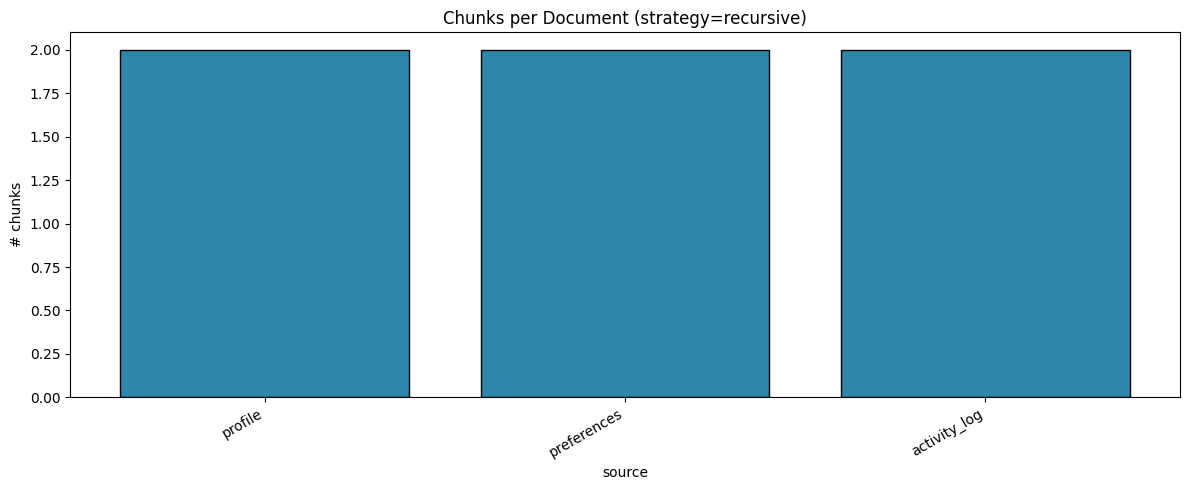

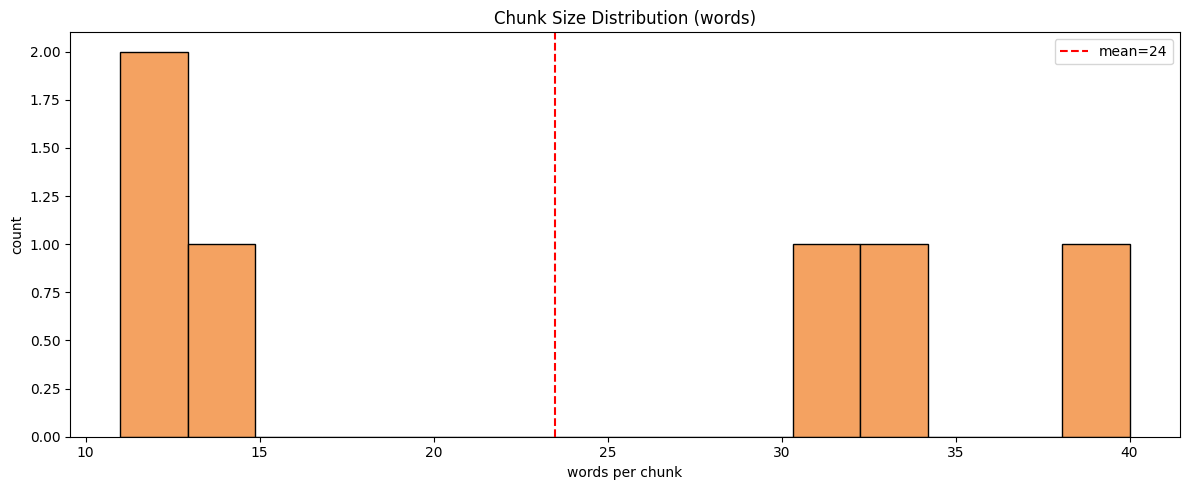

In [15]:
rag.plot_chunks()

---
## Summary & Key Takeaways

### What We Learned:
- RAG architecture and pipeline
- Document loading and preprocessing
- Chunking strategies for optimal retrieval
- Vector stores and similarity search
- Generating answers with retrieved context

### Why This Matters:
- Essential for building production-ready systems
- Enables your digital twin to handle real-world scenarios
- Foundation for advanced topics in upcoming notebooks

### Next Steps:
1. Complete all exercises in this notebook
2. Integrate concepts with your digital twin project
3. Test your implementation thoroughly
4. Move on to the next notebook in Week 2

## 🏆 Challenge Project

**Build a Complete RAG architecture and pipeline System for Your Digital Twin**

**Requirements**:
1. Apply all concepts from this notebook
2. Handle edge cases and errors gracefully
3. Include comprehensive testing
4. Create visualizations of your results
5. Document your implementation
6. Integrate with your existing digital twin code

**Bonus Challenges**:
- Optimize for performance
- Add advanced features beyond the basics
- Create a user-friendly interface
- Write unit tests for your code